
Python  3.11.15

[NumPy]
  PASS  version  →  2.4.4
  PASS  array ops  →  [2 4 6]
  PASS  dot product  →  32
  PASS  matrix multiply  →  [[19 22]
 [43 50]]
  PASS  random seed  →  [ 0.497 -0.138  0.648]
  PASS  broadcasting  →  (3, 3)

[Pandas]
  PASS  version  →  3.0.2
  PASS  DataFrame create  →  (3, 2)
  PASS  read CSV (URL)  →  (891, 12)
  PASS  groupby  →  {'v': {'a': 1.5, 'b': 3.0}}
  PASS  fillna  →  [1.0, 0.0, 3.0]

[Matplotlib]
  PASS  version  →  3.10.8
  PASS  figure create  →  Figure(640x480)


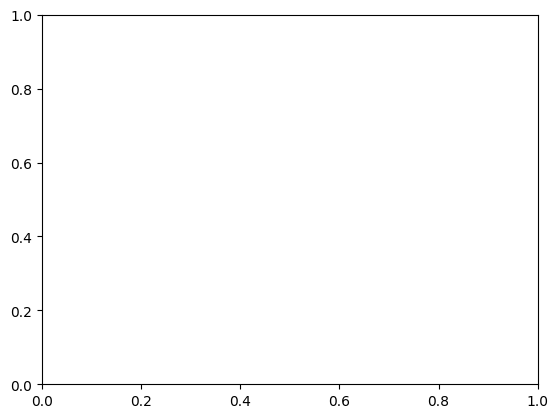

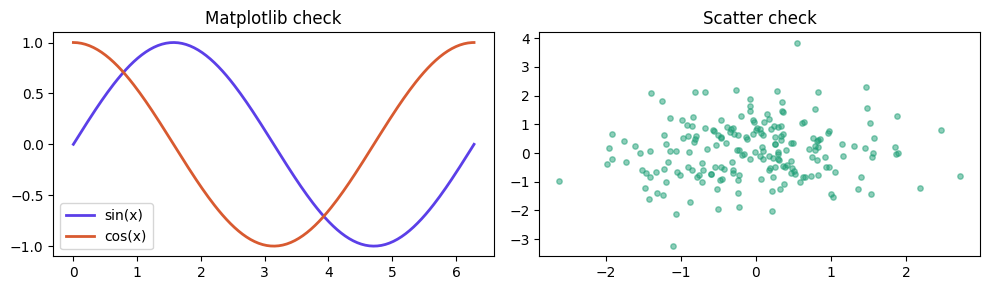

  PASS  plot rendered  →  See plots above

[Scikit-learn]
  PASS  version  →  1.8.0
  PASS  LinearRegression  →  coef shape (4,)
  PASS  LogisticRegression  →  acc 1.00
  PASS  DecisionTree  →  acc 1.00
  PASS  RandomForest  →  acc 1.00
  PASS  StandardScaler  →  mean≈0: -0.0000
  PASS  cross_val_score  →  cv scores [0.967 0.967 0.933 0.967 1.   ]

[SciPy]
  PASS  version  →  1.17.1
  PASS  stats.norm  →  pdf(0)=0.3989

[System]
  PASS  chip  →  Apple M2
  PASS  architecture  →  arm64
Build Dependencies:
  blas:
    detection method: system
    found: true
    include directory: unknown
    lib directory: unknown
    name: accelerate
    openblas configuration: unknown
    pc file directory: unknown
    version: unknown
  lapack:
    detection method: system
    found: true
    include directory: unknown
    lib directory: unknown
    name: accelerate
    openblas configuration: unknown
    pc file directory: unknown
    version: unknown
Compilers:
  c:
    commands: cc
    linker: ld6

In [1]:
# ── Day 1 Verification Suite ─────────────────────────────
# Run this in one cell. Every check prints PASS or FAIL.

import sys

def check(label, fn):
    try:
        result = fn()
        print(f"  PASS  {label}" + (f"  →  {result}" if result else ""))
    except Exception as e:
        print(f"  FAIL  {label}  →  {e}")

print(f"\nPython  {sys.version.split()[0]}")
print("=" * 52)

# ── 1. NumPy ─────────────────────────────────────────────
import numpy as np
print("\n[NumPy]")
check("version",          lambda: np.__version__)
check("array ops",        lambda: str(np.array([1,2,3]) * 2))
check("dot product",      lambda: str(np.dot([1,2,3],[4,5,6])))
check("matrix multiply",  lambda: str(np.array([[1,2],[3,4]]) @ np.array([[5,6],[7,8]])))
check("random seed",      lambda: str(np.random.seed(42) or np.random.randn(3).round(3)))
check("broadcasting",     lambda: str((np.ones((3,3)) + np.array([1,2,3])).shape))

# ── 2. Pandas ────────────────────────────────────────────
import pandas as pd
print("\n[Pandas]")
check("version",          lambda: pd.__version__)
check("DataFrame create", lambda: str(pd.DataFrame({'a':[1,2,3],'b':[4,5,6]}).shape))
check("read CSV (URL)",   lambda: str(pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv').shape))
check("groupby",          lambda: str(pd.DataFrame({'g':['a','a','b'],'v':[1,2,3]}).groupby('g').mean().to_dict()))
check("fillna",           lambda: str(pd.Series([1,None,3]).fillna(0).tolist()))

# ── 3. Matplotlib ────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
print("\n[Matplotlib]")
check("version",          lambda: matplotlib.__version__)
check("figure create",    lambda: str(plt.subplots(1,1)[0]))

x = np.linspace(0, 2*np.pi, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(x, np.sin(x), color='#5B3FE8', linewidth=2, label='sin(x)')
axes[0].plot(x, np.cos(x), color='#D85A30', linewidth=2, label='cos(x)')
axes[0].set_title('Matplotlib check')
axes[0].legend()
np.random.seed(42)
axes[1].scatter(np.random.randn(200), np.random.randn(200),
                alpha=0.5, s=15, color='#1D9E75')
axes[1].set_title('Scatter check')
plt.tight_layout()
plt.show()
check("plot rendered", lambda: "See plots above")

# ── 4. Scikit-learn ──────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
import sklearn
print("\n[Scikit-learn]")
check("version",          lambda: sklearn.__version__)

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

check("LinearRegression",    lambda: f"coef shape {LinearRegression().fit(X_train, y_train).coef_.shape}")
check("LogisticRegression",  lambda: f"acc {accuracy_score(y_test, LogisticRegression(max_iter=200).fit(X_train,y_train).predict(X_test)):.2f}")
check("DecisionTree",        lambda: f"acc {accuracy_score(y_test, DecisionTreeClassifier(random_state=42).fit(X_train,y_train).predict(X_test)):.2f}")
check("RandomForest",        lambda: f"acc {accuracy_score(y_test, RandomForestClassifier(random_state=42).fit(X_train,y_train).predict(X_test)):.2f}")
check("StandardScaler",      lambda: f"mean≈0: {StandardScaler().fit_transform(X_train).mean():.4f}")
check("cross_val_score",     lambda: f"cv scores {cross_val_score(RandomForestClassifier(random_state=42),X,y,cv=5).round(3)}")

# ── 5. SciPy ─────────────────────────────────────────────
import scipy
print("\n[SciPy]")
check("version",          lambda: scipy.__version__)
check("stats.norm",       lambda: f"pdf(0)={scipy.stats.norm.pdf(0):.4f}")

# ── 6. Apple Silicon check ───────────────────────────────
import platform, subprocess
print("\n[System]")
check("chip",             lambda: subprocess.check_output(['sysctl','-n','machdep.cpu.brand_string']).decode().strip())
check("architecture",     lambda: platform.machine())
check("numpy uses ARM",   lambda: np.show_config() or "see output above")

print("\n" + "=" * 52)
print("  Done. All PASS = you're ready for Day 2.")